# Delay Prediction in Dutch Train Services
## Model : XGBoost — Binary Classification (Retard > 5 min)

### Objective

This notebook builds upon the Logistic Regression baseline by using **XGBoost** to predict whether a train service will experience a **severe delay** (Maximum Delay > 5 minutes).

The target variable is binary:
- **0** → Retard ≤ 5 min (à l'heure ou retard modéré)
- **1** → Retard > 5 min (retard sévère)

**Pourquoi 5 minutes ?**  
Le seuil de 5 minutes représente un retard opérationnellement significatif pour les passagers (inquiétudes sur le fait que le retard va s'alonger, peur de manquer des correspondances etc). Il est aussi plus rare (~8% des services) ce qui en fait une cible utile à détecter. De plus, c'est à partir de cette durée de retard qu'il convient d'envoyer un message aux passagers pour les informer de l'évolution de la situation. Il est donc important de prévoir l'envoi de ces communications.  


**Note sur le Data Leakage**  
Toutes les features utilisées sont **disponibles avant le départ du service** (heure, jour, type de train...).  
Les features post-hoc (`std_arr_delay`, `platform_change_rate`, `any_arr_cancelled`, etc.) ont été volontairement exclues pour éviter tout leakage.

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = sns.color_palette('muted')

print(f'XGBoost version : {xgb.__version__}')

XGBoost version : 2.1.4


### 2. Loading and Preparing the Dataset

In [2]:
df_clean = pd.read_csv('df_clean.csv', low_memory=False)
print(f'df_clean loaded: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns')

# ── Datetime conversions ──────────────────────────────────────────────────────
df_clean['Service:Date']        = pd.to_datetime(df_clean['Service:Date'], errors='coerce')
df_clean['Stop:Departure time'] = pd.to_datetime(df_clean['Stop:Departure time'], utc=True, errors='coerce')

df_clean['dep_hour'] = (
    df_clean['Stop:Departure time']
    .dt.tz_convert('Europe/Amsterdam')
    .dt.hour
)

# ── Boolean → int ─────────────────────────────────────────────────────────────
bool_cols = [
    'Service:Completely cancelled',
    'Service:Partly cancelled'
]
for col in bool_cols:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col].astype(str).str.strip().str.lower()
            .map({'true': 1, 'false': 0, '1': 1, '0': 0})
            .fillna(0).astype(int)
        )

df_clean loaded: 21,838,516 rows, 17 columns


### 3. Service-Level Aggregation

Chaque ligne du dataset représente un stop. On agrège au niveau **service** (un service = un trajet complet).  
On ne garde que les features connues **avant le départ**.

In [3]:
# ── Première ligne de chaque service (contient Service:Maximum delay) ─────────
df_first = (
    df_clean
    .groupby('Service:RDT-ID', as_index=False)
    .first()
    [['Service:RDT-ID', 'Service:Date', 'Service:Type', 'Service:Company',
      'Service:Maximum delay', 'Service:Completely cancelled',
      'Service:Partly cancelled', 'dep_hour']]
)

# ── Nombre de stops par service (connu via l'horaire prévu) ───────────────────
df_agg = (
    df_clean
    .groupby('Service:RDT-ID')
    .agg(n_stops=('Stop:RDT-ID', 'count'))
    .reset_index()
)

df_service = df_first.merge(df_agg, on='Service:RDT-ID', how='left')

# ── Features temporelles ──────────────────────────────────────────────────────
df_service['month']        = df_service['Service:Date'].dt.month
df_service['day_of_week']  = df_service['Service:Date'].dt.dayofweek   # 0 = Lundi
df_service['week']         = df_service['Service:Date'].dt.isocalendar().week.astype(int)
df_service['is_weekend']   = (df_service['day_of_week'] >= 5).astype(int)
df_service['is_peak_hour'] = df_service['dep_hour'].apply(
    lambda h: 1 if pd.notna(h) and (7 <= h <= 9 or 17 <= h <= 19) else 0
)

print(f'Service-level dataset: {df_service.shape[0]:,} services, {df_service.shape[1]} columns')
df_service.head()

Service-level dataset: 2,395,636 services, 14 columns


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Maximum delay,Service:Completely cancelled,Service:Partly cancelled,dep_hour,n_stops,month,day_of_week,week,is_weekend,is_peak_hour
0,12690865,2024-01-01,Intercity,NS,2,0,0,2.0,9,1,0,1,0,0
1,12690866,2024-01-01,Nightjet,NS Int,6,0,0,2.0,8,1,0,1,0,0
2,12690867,2024-01-01,Intercity,NS,10,0,0,2.0,9,1,0,1,0,0
3,12690868,2024-01-01,Intercity,NS,5,0,0,2.0,4,1,0,1,0,0
4,12690869,2024-01-01,Stoptrein,Eurobahn,0,1,1,2.0,4,1,0,1,0,0


### 4. Defining the Binary Target Variable

$$\text{severe\_delay} = \mathbb{1}[\text{Service:Maximum delay} > 5]$$

In [1]:
df_service['severe_delay'] = (df_service['Service:Maximum delay'] > 5).astype(int)

counts = df_service['severe_delay'].value_counts()
pct    = df_service['severe_delay'].value_counts(normalize=True) * 100

print('Target variable distribution:')
print(f'  0 – Retard ≤ 15 min : {counts[0]:>10,}  ({pct[0]:.1f}%)')
print(f'  1 – Retard > 15 min : {counts[1]:>10,}  ({pct[1]:.1f}%)')

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['≤ 15 min (0)', '> 15 min (1)'],
              [counts[0], counts[1]],
              color=[PALETTE[0], PALETTE[3]],
              edgecolor='white')
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(counts)*0.01,
            f'{val:,}\n({val/sum(counts)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Nombre de services')
ax.set_title('Distribution de la variable cible (Retard > 5 min)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('viz_target_distribution.png', bbox_inches='tight')
plt.show()

NameError: name 'df_service' is not defined

### 5. Feature Selection

Seules les features **disponibles avant le départ** sont conservées :

| Feature | Type | Description |
|---|---|---|
| `Service:Type` | Catégorielle | Type de train (Intercity, Sprinter...) |
| `Service:Company` | Catégorielle | Opérateur (NS, Arriva...) |
| `month` | Numérique | Mois (1–12) |
| `week` | Numérique | Semaine ISO (1–53) |
| `day_of_week` | Numérique | Jour de la semaine (0=Lundi) |
| `dep_hour` | Numérique | Heure de départ |
| `is_weekend` | Binaire | 1 si samedi ou dimanche |
| `is_peak_hour` | Binaire | 1 si heure de pointe (7h-9h / 17h-19h) |
| `n_stops` | Numérique | Nombre de stops du service |
| `Service:Completely cancelled` | Binaire | Service entièrement annulé |
| `Service:Partly cancelled` | Binaire | Service partiellement annulé |

In [17]:
CATEGORICAL_FEATURES = ['Service:Type', 'Service:Company']
NUMERICAL_FEATURES   = [
    'month', 'week', 'day_of_week', 'dep_hour',
    'is_weekend', 'is_peak_hour',
    'n_stops',
    'Service:Completely cancelled',
    'Service:Partly cancelled'
]
TARGET = 'severe_delay'

# Encodage des variables catégorielles
df_model = df_service.copy()
le_dict  = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

ENCODED_CAT  = [c + '_enc' for c in CATEGORICAL_FEATURES]
ALL_FEATURES = NUMERICAL_FEATURES + ENCODED_CAT

df_model = df_model[ALL_FEATURES + [TARGET]].dropna()

print(f'Model dataset : {df_model.shape[0]:,} services × {len(ALL_FEATURES)} features')
print(f'Features      : {ALL_FEATURES}')

Model dataset : 2,395,608 services × 11 features
Features      : ['month', 'week', 'day_of_week', 'dep_hour', 'is_weekend', 'is_peak_hour', 'n_stops', 'Service:Completely cancelled', 'Service:Partly cancelled', 'Service:Type_enc', 'Service:Company_enc']


### 6. Train / Test Split

In [18]:
X = df_model[ALL_FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set : {X_train.shape[0]:,} services')
print(f'Test set     : {X_test.shape[0]:,} services')
print(f'\nClass distribution (train):')
print(y_train.value_counts(normalize=True).round(3))

Training set : 1,916,486 services
Test set     : 479,122 services

Class distribution (train):
severe_delay
0    0.916
1    0.084
Name: proportion, dtype: float64


### 7. XGBoost — Binary Classifier

**Paramètres clés :**
- `objective='binary:logistic'` → classification binaire, output = probabilité
- `scale_pos_weight = n_négatifs / n_positifs` → correction native du déséquilibre de classes (plus propre que les sample weights pour le binaire)
- `early_stopping_rounds=50` → arrêt automatique si la validation ne s'améliore plus
- `eval_metric='logloss'` → log-loss binaire pour le early stopping

In [19]:
# Ratio pour corriger le déséquilibre
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale = n_neg / n_pos
print(f'scale_pos_weight = {n_neg:,} / {n_pos:,} = {scale:.2f}')

xgb_model = xgb.XGBClassifier(
    objective             = 'binary:logistic',
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 10,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale,
    eval_metric           = 'logloss',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 1
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 50
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

scale_pos_weight = 1,754,706 / 161,780 = 10.85
[0]	validation_0-logloss:0.68260
[50]	validation_0-logloss:0.55822
[100]	validation_0-logloss:0.54489
[150]	validation_0-logloss:0.54015
[200]	validation_0-logloss:0.53657
[250]	validation_0-logloss:0.53404
[300]	validation_0-logloss:0.53185
[350]	validation_0-logloss:0.53003
[400]	validation_0-logloss:0.52858
[450]	validation_0-logloss:0.52735
[499]	validation_0-logloss:0.52607

Best iteration: 499


### 8. Evaluation

In [ ]:
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

acc      = accuracy_score(y_test, y_pred)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
auc_roc  = roc_auc_score(y_test, y_pred_proba)
avg_prec = average_precision_score(y_test, y_pred_proba)
f1_sev   = f1_score(y_test, y_pred, pos_label=1)
f1_w     = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print('  XGBOOST — Retard > 15 min — TEST SET RESULTS')
print('=' * 55)
print(f'  Accuracy                   : {acc:.4f}')
print(f'  Balanced Accuracy          : {bal_acc:.4f}')
print(f'  AUC-ROC                    : {auc_roc:.4f}')
print(f'  Average Precision (PR-AUC) : {avg_prec:.4f}')
print(f'  F1-score (retard sévère)   : {f1_sev:.4f}')
print(f'  F1-score (weighted avg)    : {f1_w:.4f}')
print('=' * 55)
print()
print('Detailed Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['≤ 5 min (0)', '> 5 min (1)']
))

  XGBOOST — Retard > 15 min — TEST SET RESULTS
  Accuracy                   : 0.7200
  Balanced Accuracy          : 0.7337
  AUC-ROC                    : 0.8155
  Average Precision (PR-AUC) : 0.3329
  F1-score (retard sévère)   : 0.3114
  F1-score (weighted avg)    : 0.7810

Detailed Classification Report:
              precision    recall  f1-score   support

≤ 15 min (0)       0.97      0.72      0.82    438677
> 15 min (1)       0.20      0.75      0.31     40445

    accuracy                           0.72    479122
   macro avg       0.58      0.73      0.57    479122
weighted avg       0.90      0.72      0.78    479122



### 9. Confusion Matrix

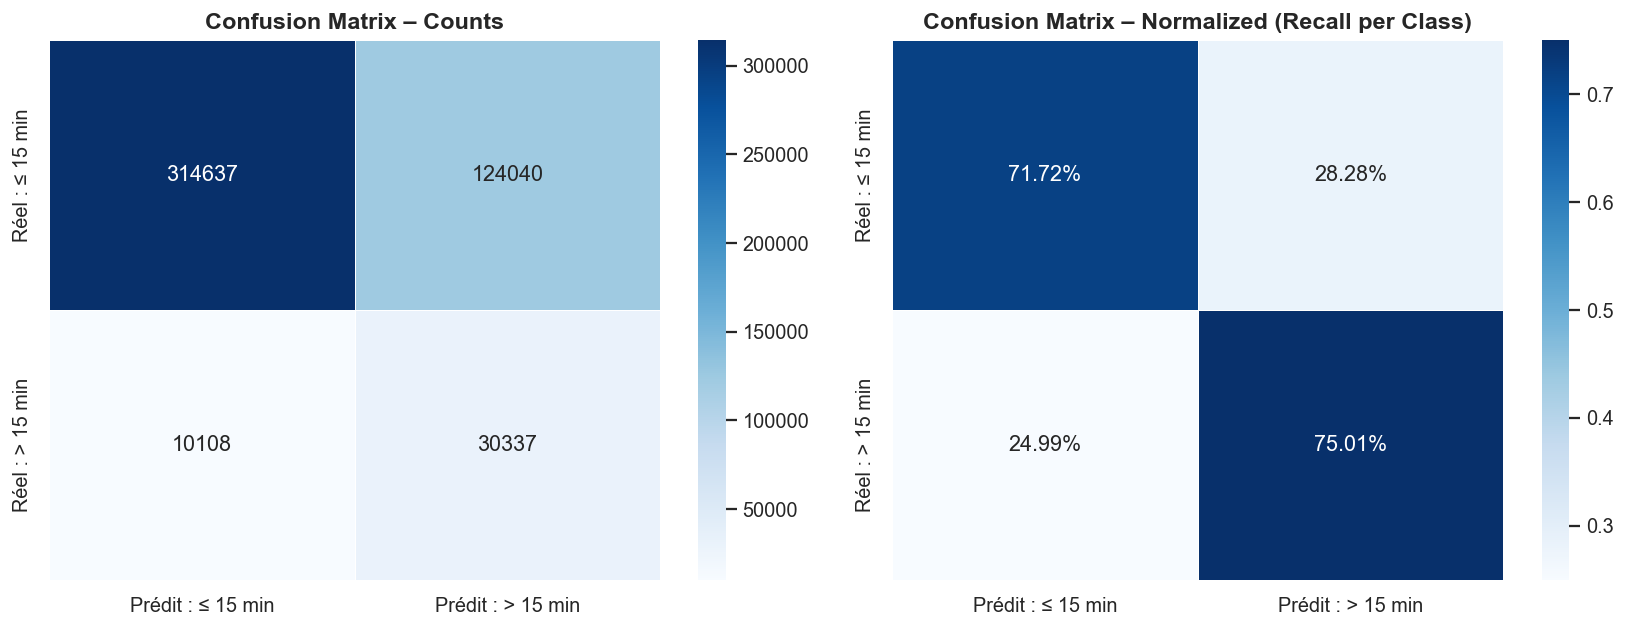

In [ ]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Prédit : ≤ 5 min', 'Prédit : > 5 min'],
            yticklabels=['Réel : ≤ 5 min', 'Réel : > 5 min'],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix – Counts', fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Prédit : ≤ 5 min', 'Prédit : > 5 min'],
            yticklabels=['Réel : ≤ 5 min', 'Réel : > 5 min'],
            linewidths=0.5, linecolor='white')
axes[1].set_title('Confusion Matrix – Normalized (Recall per Class)', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_xgb_confusion_matrix.png', bbox_inches='tight')
plt.show()

### 10. ROC Curve & Precision-Recall Curve

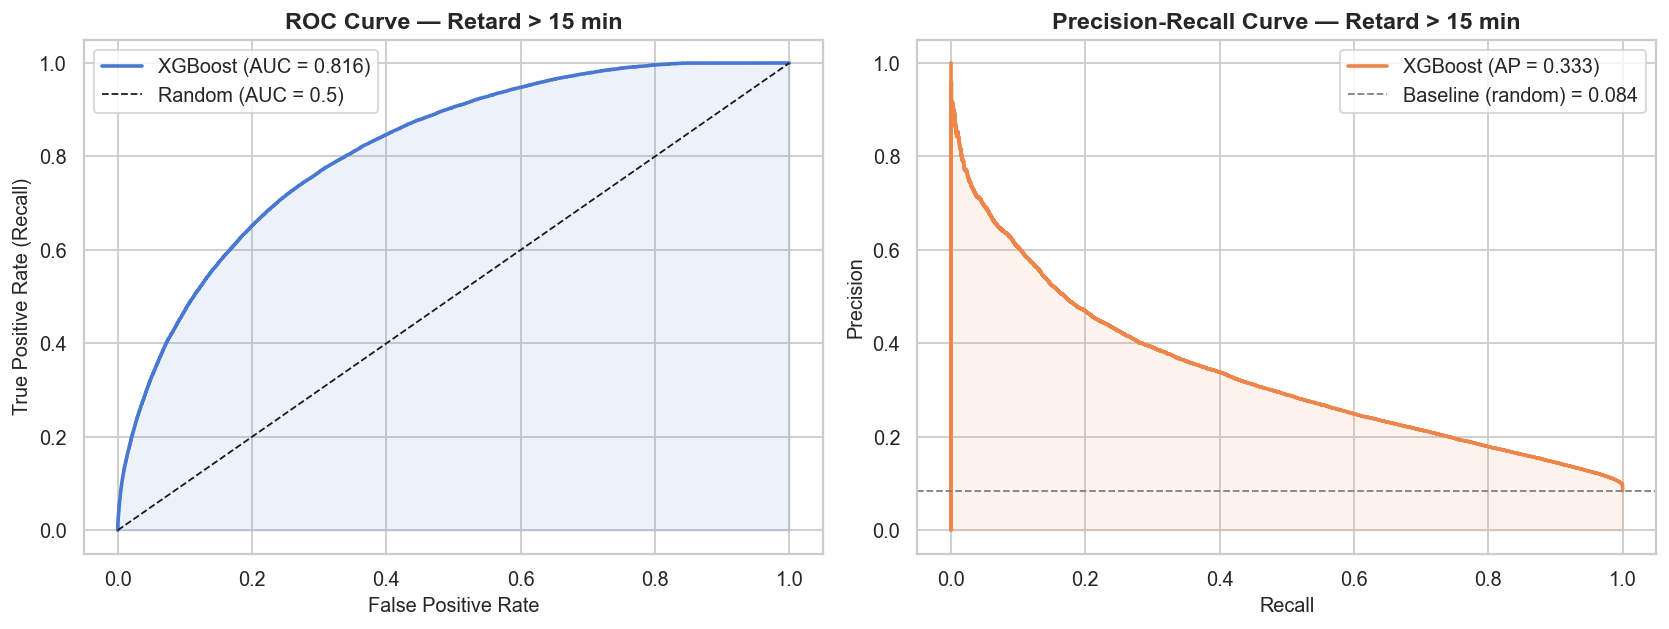

In [ ]:
fpr, tpr, _         = roc_curve(y_test, y_pred_proba)
precision, recall, _= precision_recall_curve(y_test, y_pred_proba)
baseline            = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
axes[0].plot(fpr, tpr, lw=2, color=PALETTE[0],
             label=f'XGBoost (AUC = {auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=PALETTE[0])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — Retard > 5 min', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(recall, precision, lw=2, color=PALETTE[1],
             label=f'XGBoost (AP = {avg_prec:.3f})')
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline (random) = {baseline:.3f}')
axes[1].fill_between(recall, precision, alpha=0.1, color=PALETTE[1])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Retard > 5 min', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_xgb_roc_pr.png', bbox_inches='tight')
plt.show()

### 11. Feature Importance

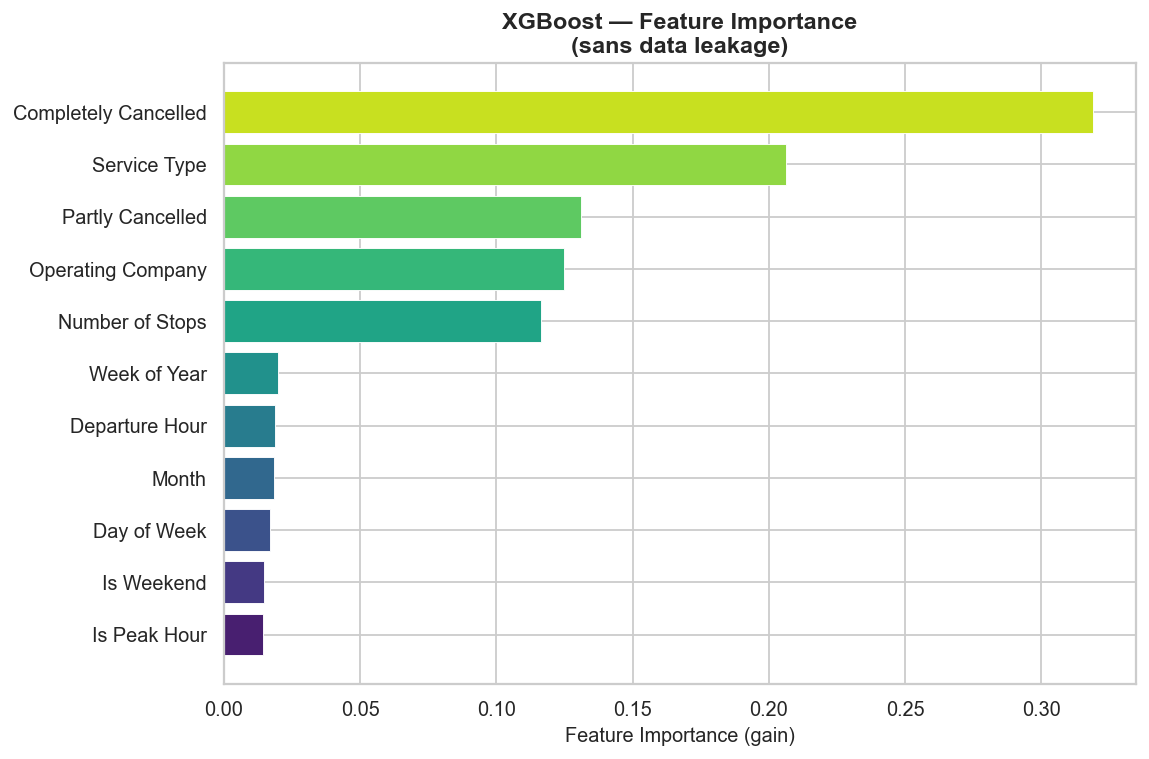

       Feature_clean  Importance
Completely Cancelled    0.318874
        Service Type    0.206460
    Partly Cancelled    0.130963
   Operating Company    0.124720
     Number of Stops    0.116348
        Week of Year    0.019832
      Departure Hour    0.018589
               Month    0.018564
         Day of Week    0.016825
          Is Weekend    0.014640
        Is Peak Hour    0.014185


In [23]:
name_map = {
    'Service:Type_enc'             : 'Service Type',
    'Service:Company_enc'          : 'Operating Company',
    'month'                        : 'Month',
    'week'                         : 'Week of Year',
    'day_of_week'                  : 'Day of Week',
    'dep_hour'                     : 'Departure Hour',
    'is_weekend'                   : 'Is Weekend',
    'is_peak_hour'                 : 'Is Peak Hour',
    'n_stops'                      : 'Number of Stops',
    'Service:Completely cancelled' : 'Completely Cancelled',
    'Service:Partly cancelled'     : 'Partly Cancelled',
}

importances = pd.DataFrame({
    'Feature'   : ALL_FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)
importances['Feature_clean'] = importances['Feature'].map(name_map).fillna(importances['Feature'])

fig, ax = plt.subplots(figsize=(9, 6))
colors  = sns.color_palette('viridis', n_colors=len(importances))
ax.barh(importances['Feature_clean'], importances['Importance'],
        color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Feature Importance\n(sans data leakage)', fontweight='bold')
plt.tight_layout()
plt.savefig('viz_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

print(importances[['Feature_clean', 'Importance']]
      .sort_values('Importance', ascending=False)
      .to_string(index=False))

### 12. Learning Curve

Visualisation de l'évolution du log-loss sur le set de validation pendant l'entraînement.  
Permet de vérifier s'il y a overfitting (validation loss qui remonte).

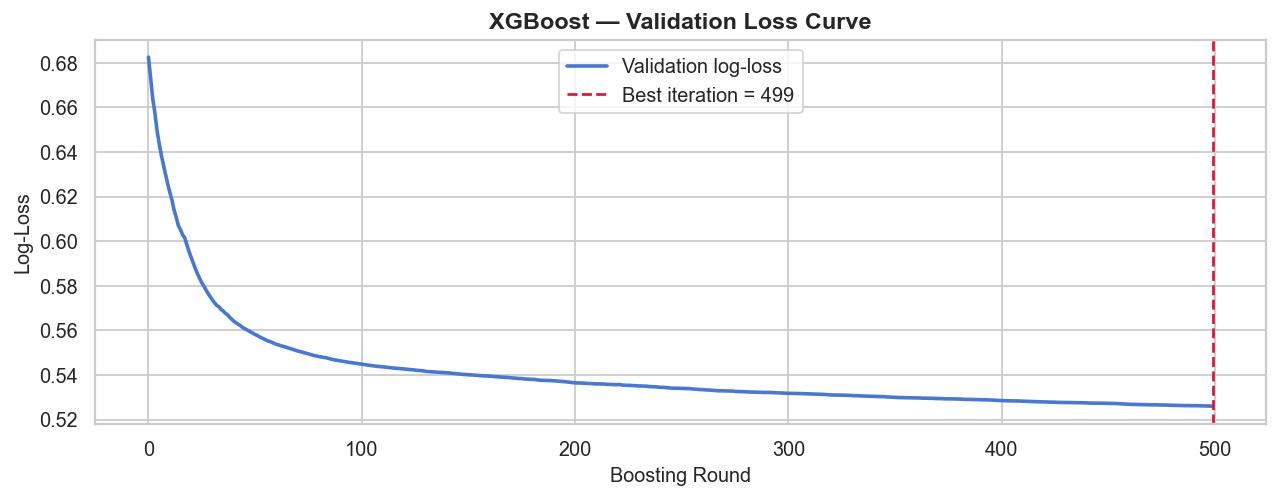

In [24]:
evals = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(evals['validation_0']['logloss'], color=PALETTE[0], linewidth=2, label='Validation log-loss')
ax.axvline(xgb_model.best_iteration, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Best iteration = {xgb_model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log-Loss')
ax.set_title('XGBoost — Validation Loss Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_xgb_learning_curve.png', bbox_inches='tight')
plt.show()

### 13. Comparaison avec la Logistic Regression

Récapitulatif des métriques clés entre les deux modèles.  
Remplace les valeurs de la LR par celles obtenues dans ton notebook précédent.

                        Model  AUC-ROC  Avg Precision  F1 (delayed cls)  Balanced Accuracy
Logistic Regression (> 5 min) 0.768000       0.264000          0.310000                NaN
           XGBoost (> 15 min) 0.815542       0.332949          0.311433           0.733661


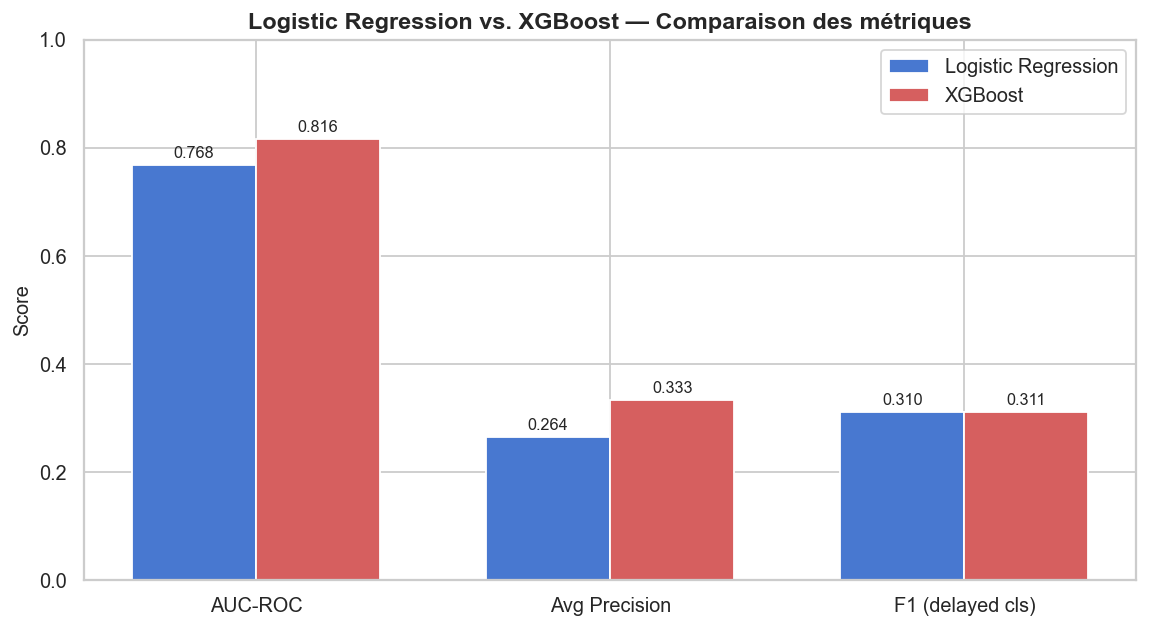

In [ ]:
# ── Remplace ici les valeurs de la Logistic Regression ───────────────────────
LR_AUC_ROC  = 0.768   # valeur obtenue dans le notebook LR
LR_AVG_PREC = 0.264
LR_F1       = 0.310
LR_BAL_ACC  = None    # non calculé dans le notebook LR

results = pd.DataFrame({
    'Model'            : ['Logistic Regression (> 5 min)', 'XGBoost (> 5 min)'],
    'AUC-ROC'          : [LR_AUC_ROC,  auc_roc],
    'Avg Precision'    : [LR_AVG_PREC, avg_prec],
    'F1 (delayed cls)' : [LR_F1,       f1_sev],
    'Balanced Accuracy': [LR_BAL_ACC,  bal_acc],
})

print(results.to_string(index=False))

# Bar chart de comparaison
metrics  = ['AUC-ROC', 'Avg Precision', 'F1 (delayed cls)']
lr_vals  = [LR_AUC_ROC, LR_AVG_PREC, LR_F1]
xgb_vals = [auc_roc, avg_prec, f1_sev]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_vals,  width, label='Logistic Regression', color=PALETTE[0])
bars2 = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',             color=PALETTE[3])

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Logistic Regression vs. XGBoost — Comparaison des métriques', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_model_comparison.png', bbox_inches='tight')
plt.show()

Seuil optimal : 0.69
F1 optimal    : 0.3683


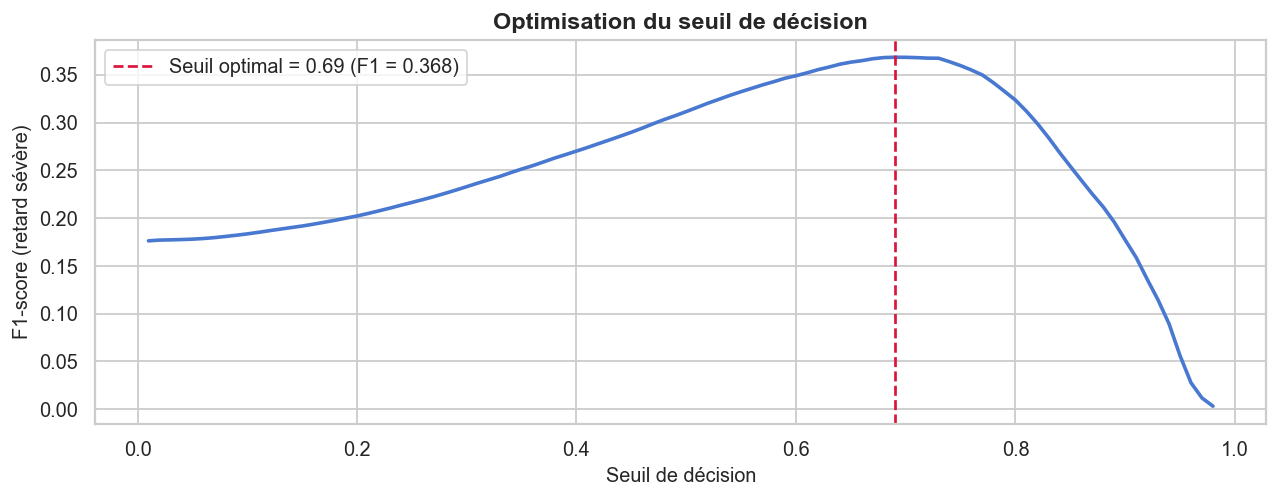


Avec le seuil optimal :
              precision    recall  f1-score   support

≤ 15 min (0)       0.95      0.90      0.92    438677
> 15 min (1)       0.30      0.47      0.37     40445

    accuracy                           0.86    479122
   macro avg       0.62      0.69      0.65    479122
weighted avg       0.89      0.86      0.88    479122



In [ ]:
from sklearn.metrics import f1_score
import numpy as np

# Tester tous les seuils entre 0.01 et 0.99
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = []

for t in thresholds:
    y_pred_t = (y_pred_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)
print(f'Seuil optimal : {best_threshold:.2f}')
print(f'F1 optimal    : {best_f1:.4f}')

# Visualisation
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color=PALETTE[0], linewidth=2)
ax.axvline(best_threshold, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Seuil optimal = {best_threshold:.2f} (F1 = {best_f1:.3f})')
ax.set_xlabel('Seuil de décision')
ax.set_ylabel('F1-score (retard sévère)')
ax.set_title('Optimisation du seuil de décision', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Réévaluation avec le seuil optimal
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
print('\nAvec le seuil optimal :')
print(classification_report(y_test, y_pred_optimal,
      target_names=['≤ 5 min (0)', '> 5 min (1)']))

              precision    recall  f1-score   support

≤ 15 min (0)       0.99      0.99      0.99    471328
> 15 min (1)       0.25      0.28      0.27      7794

    accuracy                           0.98    479122
   macro avg       0.62      0.63      0.63    479122
weighted avg       0.98      0.98      0.98    479122



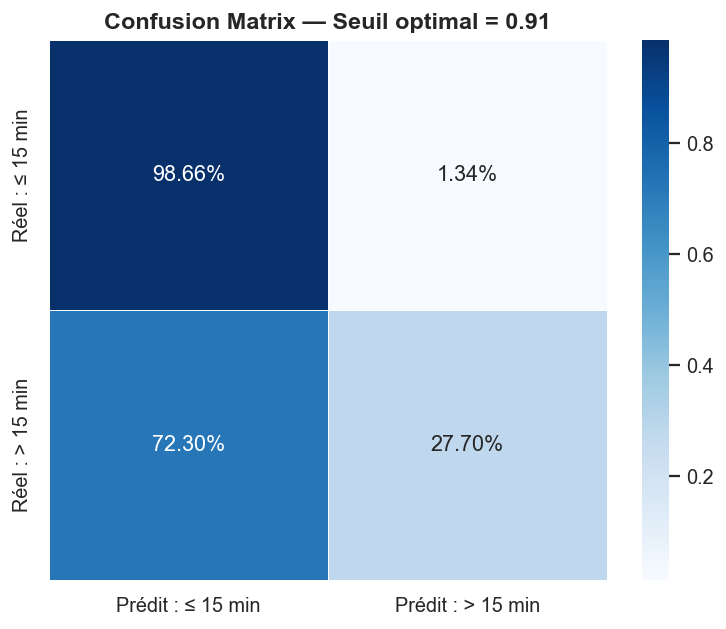

In [ ]:
y_pred_optimal = (y_pred_proba >= 0.91).astype(int)

print(classification_report(y_test, y_pred_optimal,
      target_names=['≤ 5 min (0)', '> 5 min (1)']))

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_optimal, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='.2%', cmap='Blues', ax=ax,
            xticklabels=['Prédit : ≤ 5 min', 'Prédit : > 5 min'],
            yticklabels=['Réel : ≤ 5 min', 'Réel : > 5 min'],
            linewidths=0.5, linecolor='white')
ax.set_title(f'Confusion Matrix — Seuil optimal = 0.91', fontweight='bold')
plt.tight_layout()
plt.show()